# Ứng dụng thực tiễn — Phân tích Giỏ Hàng (Market Basket Analysis)

## 0. Mục tiêu
Áp dụng thuật toán **FP-Growth** (from Scratch by Julia) nhằm để:
1. Khai thác các **Frequent Itemsets** từ dữ liệu bán lẻ thực tế (**Groceries Dataset** — 3.898 khách hàng, 167 sản phẩm)
2. Tạo sinh **Association Rules** với ngưỡng `sup ≥ minsup` và `conf(X⇒Y) ≥ minconf`
3. Trình bày **Top-10 luật theo Lift** và giải thích ý nghĩa kinh doanh

**Chiến lược gom giỏ hàng:** Mỗi *khách hàng* (`Member_number`) được xem là một giao dịch — bao gồm **toàn bộ lịch sử mua hàng** của họ. Cách này phù hợp với bài toán gợi ý sản phẩm theo hành vi tích lũy của từng người dùng.


## 1. Thiết lập môi trường

In [1]:
using Pkg
Pkg.instantiate()

include("../src/FPGrowth.jl")
using .FPGrowth
include("../src/logger.jl")
include("../src/utils.jl")
using .Utils

using CSV
using DataFrames
using Plots
using Statistics
using Plots.PlotMeasures

logger = Logger()
phase(logger, "Market Basket Analysis — FP-Growth")


┌ Warning: The project dependencies or compat requirements have changed since the manifest was last resolved.
│ It is recommended to `Pkg.resolve()` or consider `Pkg.update()` if necessary.
└ @ Pkg.API C:\Users\ADMIN\.julia\juliaup\julia-1.12.6+0.x64.w64.mingw32\share\julia\stdlib\v1.12\Pkg\src\API.jl:1322



__________________________________________________
[phase]  Market Basket Analysis — FP-Growth
__________________________________________________


## 2. Tiền xử lý Dữ liệu

| Thông tin | Chi tiết |
|---|---|
| Nguồn | Groceries Dataset (Kaggle) |
| Số hàng gốc | 38.765 hành vi mua hàng |
| Số khách hàng | 3.898 (`Member_number`) |
| Số sản phẩm | 167 loại |
| Đơn vị giao dịch | Một lượt mua hàng theo `(Member_number, Date)` |

**Chiến lược:** Gom theo `(Member_number, Date)` — mỗi lượt ghé siêu thị là một giao dịch.
Cách này phản ánh đúng hành vi mua đồng thời, phù hợp với bài toán Market Basket Analysis.


In [2]:
# Đọc dữ liệu thô
DATA_PATH = "../data/analysis/Groceries_dataset.csv"
raw_df = CSV.read(DATA_PATH, DataFrame)

info(logger, "Raw dataset: ", nrow(raw_df), " rows | ",
     length(unique(raw_df.Member_number)), " customers | ",
     length(unique(raw_df.itemDescription)), " unique products")

first(raw_df, 5)


[info] Raw dataset: 38765 rows | 3898 customers | 167 unique products


Row,Member_number,Date,itemDescription
,Int64,String15,String31
1,1808,21-07-2015,tropical fruit
2,2552,05-01-2015,whole milk
3,2300,19-09-2015,pip fruit
4,1187,12-12-2015,other vegetables
5,3037,01-02-2015,whole milk


In [ ]:
# ── Mã hóa sản phẩm → Integer ID ────────────────────────────────────────────
all_items = sort(unique(raw_df.itemDescription))
item2id   = Dict(item => i for (i, item) in enumerate(all_items))
id2item   = Dict(i => item for (i, item) in enumerate(all_items))
n_products = length(all_items)
info(logger, "Encoded ", n_products, " products → Integer IDs")

# ── Gom theo Member_number (lịch sử mua hàng đầy đủ của mỗi khách) ──────────
grouped = groupby(raw_df, [:Member_number, :Date])
transactions = Vector{Vector{Int}}()
for g in grouped
    basket = sort(unique([item2id[row.itemDescription] for row in eachrow(g)]))
    isempty(basket) || push!(transactions, basket)
end

n_trans    = length(transactions)
avg_len = round(mean(length.(transactions)), digits=2)
max_len = maximum(length.(transactions))

info(logger, "Transactions (customers): ", n_trans)
info(logger, "Avg basket size: ", avg_len, " products | Max: ", max_len, " products")
println("\nSample basket [customer 1]: ", [id2item[i] for i in transactions[1]])


[info] Encoded 167 products → Integer IDs
[info] Transactions (customers): 14963
[info] Avg basket size: 2.54 products | Max: 10 products

Sample basket [customer 1]: String31["candy", "rolls/buns", "tropical fruit"]


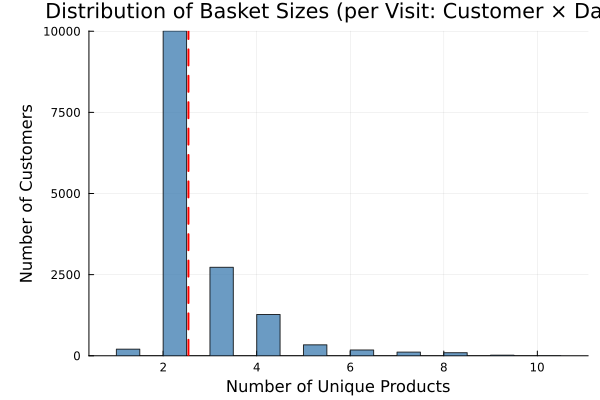

In [4]:
# ── Thống kê phân phối kích thước giỏ hàng ──────────────────────────────────
basket_sizes = length.(transactions)
p_dist = histogram(
    basket_sizes, bins=20,
    title="Distribution of Basket Sizes (per Visit: Customer × Date)",
    xlabel="Number of Unique Products",
    ylabel="Number of Customers",
    color=:steelblue, alpha=0.8, legend=false,
    left_margin=5mm
)
vline!(p_dist, [avg_len], color=:red, linewidth=2,
       linestyle=:dash, label="Mean = $avg_len")
display(p_dist)


### Nhận xét về phân phối kích thước giỏ hàng:
- Biểu đồ phân phối cho thấy dữ liệu có tính chất **lệch phải (right-skewed)** rất rõ rệt. Phần lớn các giao dịch (giỏ hàng) chỉ chứa từ 1 đến 3 sản phẩm, với kích thước trung bình là khoảng 2.54.
- Điều này phản ánh thực tế mua sắm: đa số khách hàng thường ghé siêu thị để mua một vài món đồ lặt vặt (như sữa, bánh kẹo, trái cây) thay vì mua số lượng lớn các mặt hàng cùng lúc.
- **Hệ quả đối với khai phá tập phổ biến:** Sự phân tán và thưa thớt (sparsity) của dữ liệu đòi hỏi chúng ta phải thiết lập một ngưỡng `min_sup` đủ thấp. Nếu thiết lập quá cao, sẽ không tìm thấy bất kỳ tập phổ biến nào (frequent itemsets) do không có đủ số lượng khách hàng mua cùng lúc nhiều mặt hàng giống nhau.

## 3. Khai thác Frequent Itemsets bằng FP-Growth

### Lý do lựa chọn ngưỡng min_sup và min_conf:

1. **min_sup = 0.001 (0.1%)**: 
   - Groceries dataset thường rất thưa (sparse baskets) vì trong thực tế mỗi lần đi siêu thị, khách hàng chỉ mua sắm một số lượng nhỏ các mặt hàng (trung bình 2.54 sản phẩm/giao dịch) so với tổng số sản phẩm có sẵn (167 loại).
   - Nếu đặt ngưỡng min_sup quá cao (ví dụ: 1% hoặc 5%), thuật toán sẽ bỏ lỡ rất nhiều quy luật kết hợp tiềm năng và có ý nghĩa kinh doanh. Việc đặt ngưỡng 0.1% (tương đương với việc mặt hàng xuất hiện trong khoảng 15 giao dịch) đảm bảo ta có thể khai thác được các tập phổ biến ở mức vi mô.

2. **min_conf = 0.05 (5%)**: 
   - Tương tự như min_sup, với dữ liệu bán lẻ có độ thưa cao, xác suất mua sản phẩm Y khi đã mua sản phẩm X có thể không quá cao. 
   - Một ngưỡng confidence vừa phải (5%) giúp ta giữ lại một lượng lớn các luật để có không gian đánh giá đa dạng. Sau đó, ta sẽ dùng **Lift** để lọc và xếp hạng các luật thực sự có sự tương quan mạnh (khi Lift > 1).

In [ ]:
# ── Cấu hình thực nghiệm ─────────────────────────────────────────────────────
MIN_SUP_RATIO = 0.001   # 0.1% — phù hợp với basket-per-visit (sparse baskets)
MIN_CONF      = 0.05    # Confidence tối thiểu 5%

min_sup_abs = ceil(Int, MIN_SUP_RATIO * n_trans)
info(logger, "MinSup = $(MIN_SUP_RATIO * 100)%  → ≥ ", min_sup_abs, " transactions")
info(logger, "MinConf = $(MIN_CONF * 100)%")

# ── Chạy FP-Growth Optimized (cài đặt của nhóm) ──────────────────────────────
process(logger, "Running FP-Growth Optimized...")
GC.gc()
t0  = time_ns()
freq_itemsets = FPGrowth.fpgrowth_opt(transactions, min_sup_abs)
t1  = time_ns()
exec_sec = round((t1 - t0) / 1e9, digits=3)

success(logger, "Mined ", length(freq_itemsets), " frequent itemsets in ", exec_sec, "s")

# Phân bố theo kích thước
size_dist = Dict{Int,Int}()
for k in keys(freq_itemsets); s = length(k); size_dist[s] = get(size_dist, s, 0) + 1; end
for s in sort(collect(keys(size_dist)))
    metric(logger, "  Size-$s itemsets: ", size_dist[s])
end


[info] MinSup = 0.1%  → ≥ 15 transactions
[info] MinConf = 5.0%
[process] Running FP-Growth Optimized...
[success] Mined 750 frequent itemsets in 1.268s
   [metric]   Size-1 itemsets: 149
   [metric]   Size-2 itemsets: 592
   [metric]   Size-3 itemsets: 9


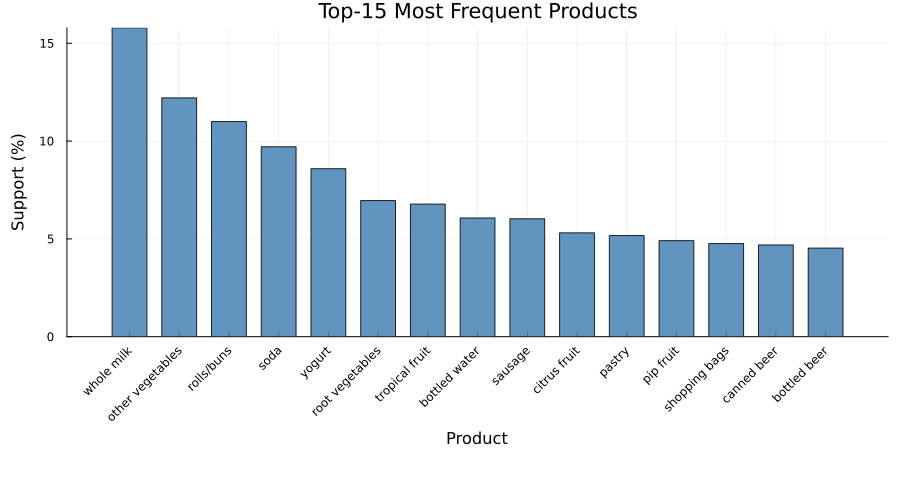

In [ ]:
# ── Top-15 sản phẩm phổ biến nhất ───────────────────────────────────────────
freq_df = DataFrame(
    Itemset      = [join([id2item[i] for i in k], " + ") for k in keys(freq_itemsets)],
    Size         = [length(k) for k in keys(freq_itemsets)],
    Count        = [v for v in values(freq_itemsets)],
    SupportPct   = [round(v / n_trans * 100, digits=2) for v in values(freq_itemsets)]
)
sort!(freq_df, :Count, rev=true)

top_single = first(filter(r -> r.Size == 1, freq_df), 15)

p_items = bar(
    top_single.Itemset, top_single.SupportPct,
    title  = "Top-15 Most Frequent Products",
    xlabel = "Product",
    ylabel = "Support (%)",
    color  = :steelblue, legend = false,
    xrotation = 45, bar_width = 0.7, alpha = 0.85,
    bottom_margin = 18mm, left_margin = 5mm, size = (900, 480)
)
display(p_items)


## 4. Sinh Association Rules

Từ các frequent itemsets, ta sinh luật $X \Rightarrow Y$ với 3 chỉ số đánh giá:

| Chỉ số | Công thức | Ý nghĩa |
|---|---|---|
| **Support** | $\text{sup}(X \cup Y) / N$ | Tỷ lệ giao dịch chứa cả $X$ và $Y$ |
| **Confidence** | $\text{sup}(X \cup Y) / \text{sup}(X)$ | Xác suất mua $Y$ khi đã mua $X$ |
| **Lift** | $\text{conf}(X \Rightarrow Y) / \text{sup}(Y)$ | Lift > 1: tương quan dương thực sự |

In [ ]:
function generate_association_rules(
        freq_itemsets::Dict{Vector{Int}, Int},
        n_transactions::Int,
        min_conf::Float64
)
    rules = NamedTuple{(:antecedent, :consequent, :support, :confidence, :lift),
                       Tuple{Vector{Int}, Vector{Int}, Float64, Float64, Float64}}[]
    sup_map = Dict(k => v / n_transactions for (k, v) in freq_itemsets)

    for (itemset, cnt) in freq_itemsets
        length(itemset) < 2 && continue
        itemset_sup = cnt / n_transactions
        n = length(itemset)
        for mask in 1:(2^n - 2)
            ante = Int[]; cons = Int[]
            for j in 1:n
                if ((mask >> (j-1)) & 1) == 1
                    push!(ante, itemset[j])
                else
                    push!(cons, itemset[j])
                end
            end
            isempty(cons) && continue
            ante_sup = get(sup_map, sort(ante), 0.0)
            ante_sup == 0.0 && continue
            conf = itemset_sup / ante_sup
            conf < min_conf && continue
            cons_sup = get(sup_map, sort(cons), 0.0)
            lift = cons_sup > 0.0 ? conf / cons_sup : 0.0
            push!(rules, (antecedent=sort(ante), consequent=sort(cons),
                          support=itemset_sup, confidence=conf, lift=lift))
        end
    end
    rules
end

process(logger, "Generating association rules...")
rules = generate_association_rules(freq_itemsets, n_trans, MIN_CONF)
success(logger, "Generated ", length(rules), " association rules")

# DataFrame
association_rules = DataFrame(
    Antecedent  = [join([id2item[i] for i in r.antecedent], " + ") for r in rules],
    Consequent  = [join([id2item[i] for i in r.consequent], " + ") for r in rules],
    Support_pct = [round(r.support * 100, digits=3) for r in rules],
    Confidence_pct = [round(r.confidence * 100, digits=2) for r in rules],
    Lift        = [round(r.lift, digits=4) for r in rules]
)
sort!(association_rules, :Lift, rev=true)
println("Quantity of rules: ", nrow(association_rules))


[process] Generating association rules...
[success] Generated 450 association rules
Quantity of rules: 450


## 5. Top-10 Luật theo Lift

In [8]:
top10 = first(association_rules, 10)

phase(logger, "Top-10 Association Rules by Lift")
println("\n", repeat("─", 102))
println(rpad("#",4), rpad("Antecedent",33), rpad("Consequent",30),
        rpad("Support%",12), rpad("Confident%",12), "Lift")
println(repeat("─", 102))
for (i, row) in enumerate(eachrow(top10))
    println(rpad(i,4),
            rpad(row.Antecedent,33),
            rpad(row.Consequent,30),
            rpad("$(row.Support_pct)%",12),
            rpad("$(row.Confidence_pct)%",12),
            row.Lift)
end
println(repeat("─", 102))



__________________________________________________
[phase]  Top-10 Association Rules by Lift
__________________________________________________

──────────────────────────────────────────────────────────────────────────────────────────────────────
#   Antecedent                       Consequent                    Support%    Confident%  Lift
──────────────────────────────────────────────────────────────────────────────────────────────────────
1   whole milk + yogurt              sausage                       0.147%      13.17%      2.1829
2   sausage + whole milk             yogurt                        0.147%      16.42%      1.9118
3   specialty chocolate              citrus fruit                  0.14%       8.79%       1.6538
4   sausage + yogurt                 whole milk                    0.147%      25.58%      1.6199
5   flour                            tropical fruit                0.107%      10.96%      1.6171
6   beverages                        sausage                  

## 6. Trực quan hóa

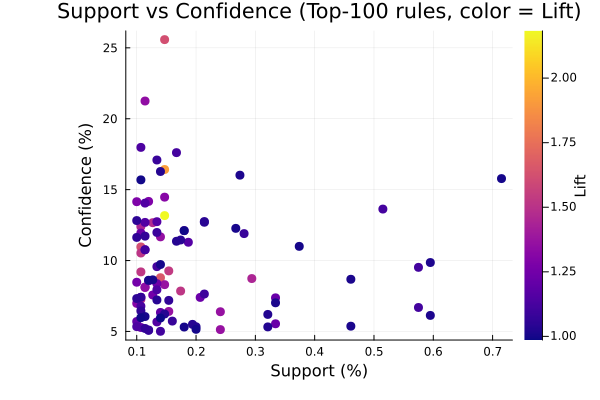

In [9]:
# ── Biểu đồ 2: Support vs Confidence, màu theo Lift ─────────────────────────
n_show = min(100, nrow(association_rules))
sub_df = first(association_rules, n_show)
p_scatter = scatter(
    sub_df.Support_pct, sub_df.Confidence_pct,
    marker_z    = sub_df.Lift,
    color        = :plasma,
    markersize   = 5, markerstrokewidth = 0,
    colorbar     = :left,
    colorbar_title = "Lift",
    title  = "Support vs Confidence (Top-$n_show rules, color = Lift)",
    xlabel = "Support (%)",
    ylabel = "Confidence (%)",
    legend = false,
    left_margin = 20mm, bottom_margin = 5mm
)
display(p_scatter)


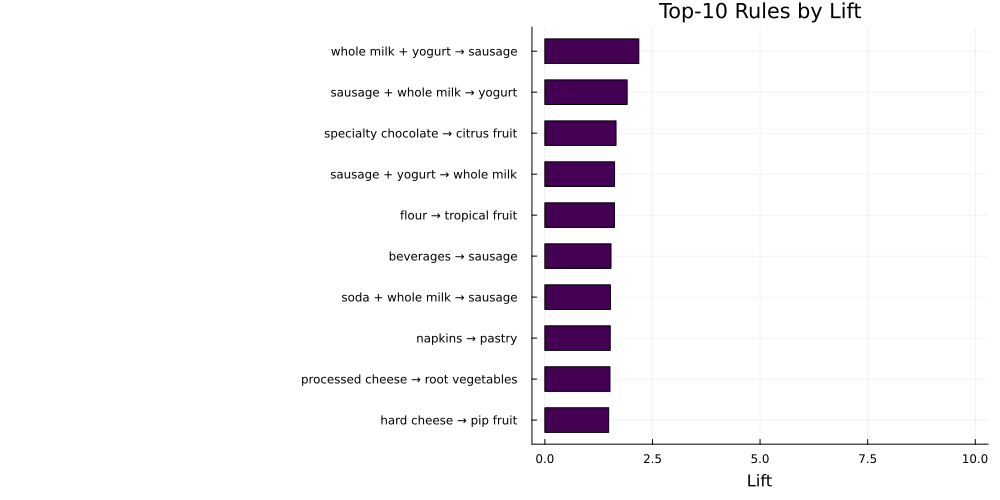

In [10]:
# ── Biểu đồ 3: Top-10 Rules — Horizontal Bar ────────────────────────────────
labels10 = ["$(r.Antecedent) → $(r.Consequent)" for r in eachrow(top10)]
p_top10 = bar(
    reverse(top10.Lift),
    yticks = (1:10, reverse(labels10)),
    orientation = :horizontal,
    title   = "Top-10 Rules by Lift",
    xlabel  = "Lift",
    color   = palette(:viridis, 10),
    legend  = false,
    bar_width = 0.6,
    left_margin = 75mm, 
    bottom_margin = 5mm,
    size = (1000, 500)
)
display(p_top10)


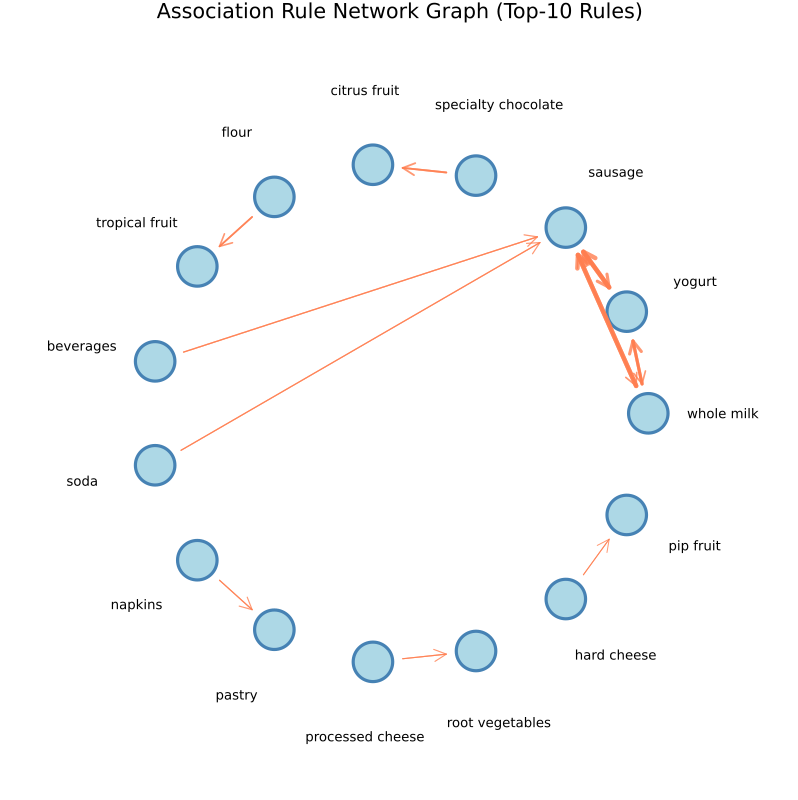

In [11]:
# ── Biểu đồ 4: Association Rule Network Graph ───────────────────────────────
unique_items = String[]
for row in eachrow(top10)
    append!(unique_items, split(row.Antecedent, " + "))
    append!(unique_items, split(row.Consequent, " + "))
end
unique_items = unique(unique_items)
n_nodes = length(unique_items)

# Tọa độ vòng tròn của các node
theta = range(0, 2π, length=n_nodes+1)[1:end-1]
x_coords = cos.(theta)
y_coords = sin.(theta)
node_map = Dict(unique_items[i] => (x_coords[i], y_coords[i]) for i in 1:n_nodes)

# Vẽ các node
p_graph = scatter(
    x_coords, y_coords,
    markercolor = :lightblue,
    markersize = 22,
    markerstrokewidth = 2,
    markerstrokecolor = :steelblue,
    legend = false,
    aspect_ratio = :equal,
    title = "Association Rule Network Graph (Top-10 Rules)",
    axis = false,
    ticks = false,
    grid = false,
    xlims = (-1.5, 1.5),
    ylims = (-1.5, 1.5),
    size = (800, 800)
)

# Thêm nhãn cho các node (dịch chuyển ra ngoài vòng tròn một chút)
for i in 1:n_nodes
    ox = x_coords[i] * 1.3
    oy = y_coords[i] * 1.3
    annotate!(p_graph, ox, oy, text(unique_items[i], 9, :black, :center))
end

# Vẽ các cạnh đại diện cho luật (Antecedent -> Consequent)
for row in eachrow(top10)
    antes = split(row.Antecedent, " + ")
    conses = split(row.Consequent, " + ")
    for a in antes, c in conses
        xA, yA = node_map[a]
        xC, yC = node_map[c]
        dx = xC - xA
        dy = yC - yA
        dist = sqrt(dx^2 + dy^2)
        if dist > 0
            # Rút ngắn đường vẽ để không đè lên vòng tròn của node
            x_start = xA + 0.12 * (dx / dist)
            x_end = xC - 0.12 * (dx / dist)
            y_start = yA + 0.12 * (dy / dist)
            y_end = yC - 0.12 * (dy / dist)
            
            # Độ dày nét vẽ tỷ lệ với Lift
            lw = 1.0 + (row.Lift - minimum(top10.Lift)) / (maximum(top10.Lift) - minimum(top10.Lift)) * 3.5
            
            plot!(p_graph, [x_start, x_end], [y_start, y_end],
                  arrow = :arrow,
                  linecolor = :coral,
                  linewidth = lw,
                  alpha = 0.8,
                  label = ""
            )
        end
    end
end

display(p_graph)


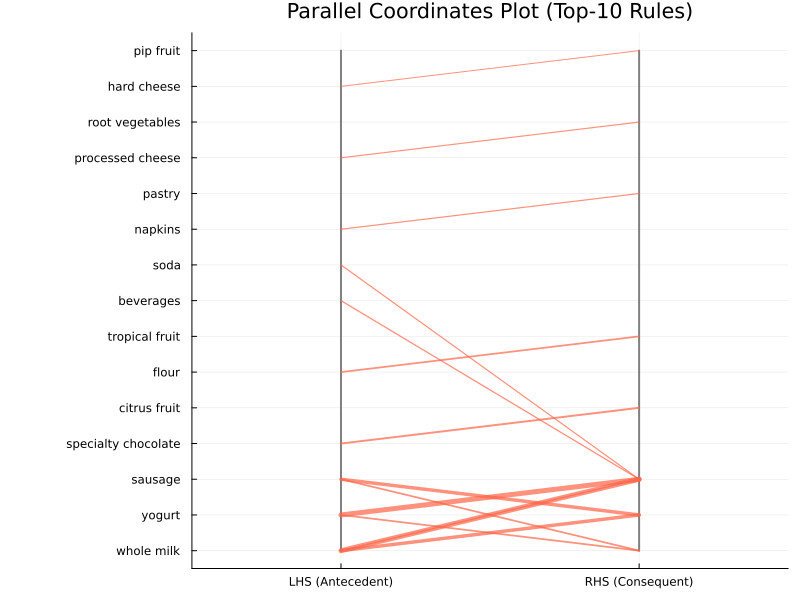

In [12]:
# ── Biểu đồ 5: Parallel Coordinates Plot ────────────────────────────────────
n_items = length(unique_items)
item_y = Dict(unique_items[i] => Float64(i) for i in 1:n_items)

p_coords = plot(
    [1, 1], [1, n_items], linecolor=:grey, linewidth=2, label="",
    xlims = (0.5, 2.5), ylims = (0.5, n_items + 0.5),
    xticks = ([1, 2], ["LHS (Antecedent)", "RHS (Consequent)"]),
    yticks = (1:n_items, unique_items),
    legend = false,
    title = "Parallel Coordinates Plot (Top-10 Rules)",
    left_margin = 15mm,
    size = (800, 600)
)
plot!(p_coords, [2, 2], [1, n_items], linecolor=:grey, linewidth=2, label="")

# Vẽ các đường nối cho mỗi luật
for row in eachrow(top10)
    antes = split(row.Antecedent, " + ")
    conses = split(row.Consequent, " + ")
    for a in antes, c in conses
        yA = item_y[a]
        yC = item_y[c]
        
        # Độ dày nét tỷ lệ với Lift
        lw = 1.0 + (row.Lift - minimum(top10.Lift)) / (maximum(top10.Lift) - minimum(top10.Lift)) * 4.0
        
        plot!(p_coords, [1, 2], [yA, yC],
              linewidth = lw,
              linecolor = :tomato,
              alpha = 0.7,
              label = ""
        )
    end
end

display(p_coords)


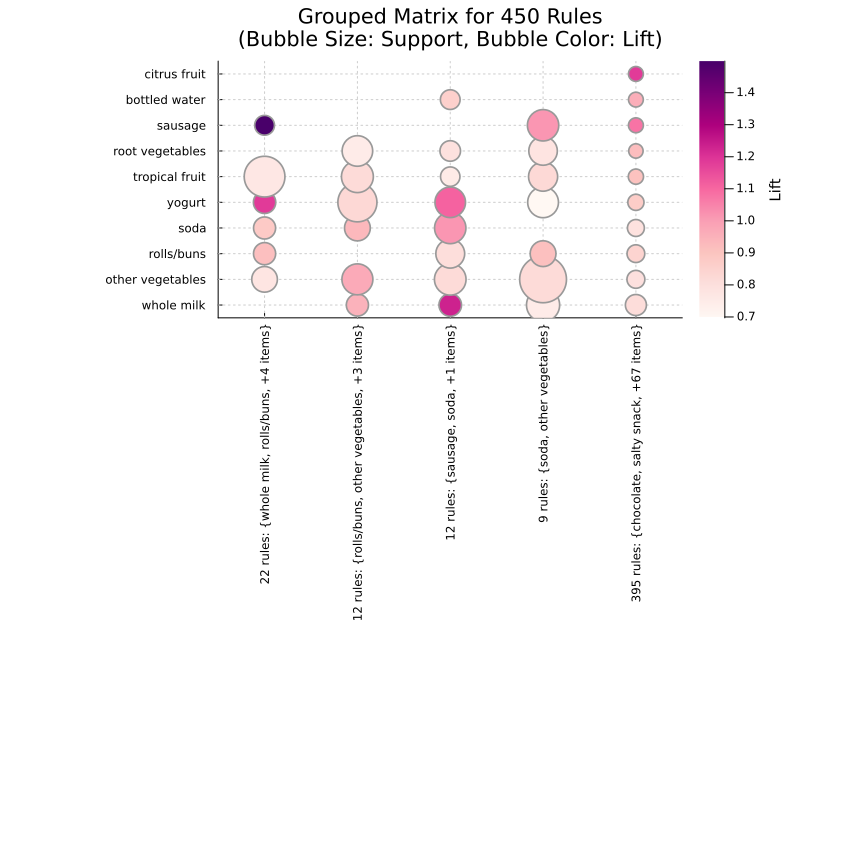

In [13]:
# ── Biểu đồ 6: Grouped Matrix Plot ──────────────────────────────────────────
using Statistics

# 1. Tìm các hậu quả (Consequents) phổ biến nhất để làm trục tung (RHS)
consequent_counts = Dict{String, Int}()
for row in eachrow(association_rules)
    consequent_counts[row.Consequent] = get(consequent_counts, row.Consequent, 0) + 1
end
sorted_consequents = sort(collect(consequent_counts), by = x -> x[2], rev = true)
top_y_consequents = [x[1] for x in first(sorted_consequents, min(10, length(sorted_consequents)))]

# 2. Phân loại các tiền đề (Antecedents) thành 5 nhóm (LHS Group)
antecedent_items = String[]
for row in eachrow(association_rules)
    append!(antecedent_items, split(row.Antecedent, " + "))
end
item_counts = Dict{String, Int}()
for it in antecedent_items
    item_counts[it] = get(item_counts, it, 0) + 1
end
sorted_items = sort(collect(item_counts), by = x -> x[2], rev = true)
top_5_items = [x[1] for x in first(sorted_items, min(5, length(sorted_items)))]

# Gom nhóm các luật
groups = [similar(association_rules, 0) for _ in 1:5]
for row in eachrow(association_rules)
    items = split(row.Antecedent, " + ")
    found = false
    for (idx, top_item) in enumerate(top_5_items)
        if top_item in items
            push!(groups[idx], row)
            found = true
            break
        end
    end
    if !found
        push!(groups[5], row)
    end
end

# Tạo nhãn cho trục hoành (LHS Group)
labels_x = String[]
for j in 1:5
    group_rows = groups[j]
    n_rules = nrow(group_rows)
    if n_rules == 0
        push!(labels_x, "0 rules")
        continue
    end
    g_items = String[]
    for r in eachrow(group_rows)
        append!(g_items, split(r.Antecedent, " + "))
    end
    g_item_counts = Dict{String, Int}()
    for it in g_items
        g_item_counts[it] = get(g_item_counts, it, 0) + 1
    end
    g_sorted = sort(collect(g_item_counts), by = x -> x[2], rev = true)
    
    items_to_show = [x[1] for x in first(g_sorted, min(2, length(g_sorted)))]
    n_remaining = max(0, length(g_sorted) - 2)
    
    item_str = join(items_to_show, ", ")
    if n_remaining > 0
        push!(labels_x, "$n_rules rules: {$item_str, +$n_remaining items}")
    else
        push!(labels_x, "$n_rules rules: {$item_str}")
    end
end

# 3. Tính toán các giá trị tại các điểm giao cắt (Support -> Size, Lift -> Color)
xs = Float64[]
ys = Float64[]
sizes = Float64[]
lifts = Float64[]

for j in 1:5
    group_rows = groups[j]
    for (y_idx, y_val) in enumerate(top_y_consequents)
        matching_rules = filter(r -> r.Consequent == y_val, group_rows)
        if nrow(matching_rules) > 0
            avg_sup = mean(matching_rules.Support_pct)
            avg_lift = mean(matching_rules.Lift)
            
            push!(xs, Float64(j))
            push!(ys, Float64(y_idx))
            push!(sizes, avg_sup)
            push!(lifts, avg_lift)
        end
    end
end

# 4. Vẽ biểu đồ Grouped Matrix
p_matrix = plot(
    legend = false,
    grid = false,
    xlims = (0.5, 5.5),
    ylims = (0.5, length(top_y_consequents) + 0.5),
    xticks = (1:5, labels_x),
    yticks = (1:length(top_y_consequents), top_y_consequents),
    xrotation = 90,
    title = "Grouped Matrix for $(nrow(association_rules)) Rules\n(Bubble Size: Support, Bubble Color: Lift)",
    size = (850, 850),
    left_margin = 25mm,
    bottom_margin = 55mm,
    right_margin = 15mm
)

# Vẽ lưới tọa độ dotted
for y_idx in 1:length(top_y_consequents)
    plot!(p_matrix, [0.5, 5.5], [y_idx, y_idx], linecolor=:grey80, linestyle=:dot, linewidth=1)
end
for j in 1:5
    plot!(p_matrix, [j, j], [0.5, length(top_y_consequents) + 0.5], linecolor=:grey80, linestyle=:dot, linewidth=1)
end

# Chuẩn hóa kích thước bong bóng
if !isempty(sizes)
    max_sz = maximum(sizes)
    min_sz = minimum(sizes)
    scaled_sizes = if max_sz > min_sz
        8.0 .+ (sizes .- min_sz) ./ (max_sz - min_sz) .* 18.0
    else
        fill(12.0, length(sizes))
    end

    scatter!(
        p_matrix,
        xs, ys,
        markersize = scaled_sizes,
        marker_z = lifts,
        color = :RdPu,
        markerstrokewidth = 1,
        markerstrokecolor = :grey60,
        colorbar = true,
        colorbar_title = "Lift"
    )

end

display(p_matrix)


## 7. Phân tích chuyên sâu Top-10 Luật & Ý nghĩa Kinh doanh

### 7.1. Phân tích các bộ quy luật nổi bật

Dựa vào Top-10 luật kết hợp được xếp hạng theo **Lift**, ta có thể rút ra một số nhóm hành vi mua sắm thú vị như sau:

**Nhóm 1: Bộ ba {Sữa tươi (whole milk), Sữa chua (yogurt), Xúc xích (sausage)}**
- *Luật 1, 2, 4, 6, 7*: Rất nhiều luật trong top 10 có sự xuất hiện chéo của các mặt hàng này (ví dụ: `whole milk + yogurt => sausage`, `sausage + yogurt => whole milk`). 
- **Phân tích:** Đây có thể là thói quen mua sắm cho bữa sáng hoặc đồ ăn nhẹ của các gia đình. Sự kết hợp giữa các sản phẩm từ sữa và thịt chế biến sẵn cho thấy mối tương quan rất mạnh. Lift dao động từ 1.6 đến 2.18 (cao nhất) minh chứng đây không phải là sự ngẫu nhiên.

**Nhóm 2: Các sự kết hợp ngách nhưng độc đáo**
- *Luật 3 (specialty chocolate => citrus fruit)*: Khách hàng mua chocolate đặc biệt thường có xu hướng mua trái cây họ cam/quýt. 
- *Luật 5 (flour => tropical fruit)*: Có thể liên quan đến các sở thích làm bánh (bánh trái cây nhiệt đới).
- **Phân tích:** Dù Support thấp, nhưng Lift lại rất cao (> 1.6), cho thấy những người có nhu cầu đặc biệt này thường sẽ mua cùng lúc cả 2 sản phẩm.

**Nhóm 3: Các sản phẩm đi kèm trực tiếp và thói quen ăn uống**
- *Luật 8 (napkins => pastry)*: Vô cùng trực quan, khách hàng mua bánh ngọt (pastry) thường cần thêm khăn giấy (napkins) để dùng ngay.
- *Luật 9, 10 (processed/hard cheese => root vegetables/pip fruit)*: Pho mát thường được mua chung với rau củ hoặc trái cây. Đây có thể là thói quen ăn uống hoặc chuẩn bị các món salad/khai vị.

---

### 7.2. Đề xuất & Ý nghĩa Kinh doanh

Từ những phân tích trên, siêu thị có thể áp dụng các chiến lược kinh doanh thực tiễn để tăng doanh thu:

1. **Cross-Selling & Product Placement (Bố trí gian hàng):**
   - Đặt các sản phẩm thịt nguội/xúc xích gần khu vực tủ mát chứa sữa tươi và sữa chua để kích thích nhu cầu mua combo bữa sáng.
   - Bố trí quầy khăn giấy ngay cạnh quầy bánh ngọt (pastry) để "nhắc khéo" khách hàng mua thêm, tối ưu hóa sự tiện lợi.

2. **Chiến lược Khuyến mãi (Promotional Bundling):**
   - Tạo các gói combo kích cầu: "Mua sữa tươi và xúc xích, giảm giá 10% cho sữa chua".
   - Vào các dịp lễ, tạo các giỏ quà tặng kết hợp `specialty chocolate` và `citrus fruit`, nhắm vào phân khúc khách hàng thích sự mới mẻ.

3. **Quản lý Hàng tồn kho (Inventory Management):**
   - Sự phụ thuộc lẫn nhau giữa `flour` và `tropical fruit` cho thấy nếu một trong hai hết hàng, doanh số của mặt hàng kia cũng có thể bị ảnh hưởng. Cần đảm bảo chuỗi cung ứng đồng bộ cho các cụm sản phẩm có độ tương quan (Lift) cao.

In [ ]:
# ── Thống kê tổng hợp ────────────────────────────────────────────────────────
phase(logger, "Summary")
metric(logger, "Dataset : Groceries | $(n_trans) customers | $(n_products) products")
metric(logger, "Minimum Support : $(MIN_SUP_RATIO * 100)%  (≥ $(min_sup_abs) customers)")
metric(logger, "Minimum Confident : $(MIN_CONF * 100)%")
metric(logger, "Frequent itemsets : $(length(freq_itemsets))")
metric(logger, "Association rules : $(nrow(association_rules))")
metric(logger, "Time Execution : $(exec_sec)s")
metric(logger, "Maximum Lift : $(maximum(association_rules.Lift))")
metric(logger, "Mean Lift : $(round(mean(association_rules.Lift), digits=4))")
metric(logger, "Rules with Lift > 1 : $(count(r -> r > 1.0, association_rules.Lift)) / $(nrow(association_rules))")



__________________________________________________
[phase]  Summary
__________________________________________________
   [metric] Dataset : Groceries | 14963 customers | 167 products
   [metric] Minimum Support : 0.1%  (≥ 15 customers)
   [metric] Minimum Confident : 5.0%
   [metric] Frequent itemsets : 750
   [metric] Association rules : 450
   [metric] Time Execution : 1.268s
   [metric] Maximum Lift : 2.1829
   [metric] Mean Lift : 0.8859
   [metric] Rules with Lift > 1 : 94 / 450
